In [ ]:
import gc
import os

import cv2
import numpy as np
import torch
from IPython.display import display
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms

# dataset
from transformers import AutoModelForImageSegmentation, BitsAndBytesConfig, SamModel, SamProcessor

from constant import ROOT, device
from ML_SERVER.birefnet import biref_process
from utils.utils import center, mask_crop, pic2float, pic2pil, sigmoid

MODEL_NAME = "facebook/sam-vit-base"
# MODEL_NAME = "facebook/sam-vit-large"
# MODEL_NAME = "facebook/sam-vit-huge"
DTYPE = torch.float16

In [ ]:
def advanced_mask(logits, threshold=0.5, sigma=5, alpha=10):
    """
    Создает сложную маску с чёткими внутренними объектами и мягкими границами.

    :param logits: Логиты (numpy массив)
    :param threshold: Порог для бинаризации
    :param sigma: Параметр размытия для сглаживания границ
    :param alpha: Коэффициент крутизны для сигмоиды
    :return: Маска с плавными границами (numpy массив)
    """
    # 1. Бинаризация логитов
    binary_mask = (sigmoid(logits) >= threshold).astype(np.float32)  # Бинарная маска

    # 2. Размытие бинарной маски для выделения границ
    blurred_binary = cv2.GaussianBlur(binary_mask, (0, 0), sigma)

    # Нормализация размытой маски (для диапазона 0-1)
    blurred_binary = 0.25 - (blurred_binary - 0.5) ** 2
    blurred_binary = cv2.GaussianBlur(blurred_binary, (0, 0), sigma)

    blurred_binary = blurred_binary / np.max(blurred_binary)
    blurred_binary = np.clip(blurred_binary, 0, 1)
    # print(blurred_binary.max(), blurred_binary.min())

    # return blurred_binary
    # 3. Применение размытой маски к сигмоиде
    alpha = 4
    soft_mask = 1 / (1 + np.exp(-alpha * (sigmoid - threshold)))  # Сигмоидная маска
    soft_mask = 1 * (sigmoid - 0.5) + 0.5

    # binary_mask = cv2.GaussianBlur(binary_mask, (0, 0), 1)

    final_mask = soft_mask * blurred_binary + binary_mask * (1 - blurred_binary)
    final_mask = np.clip(final_mask, 0, 1)

    return final_mask

In [3]:
model = SamModel.from_pretrained(MODEL_NAME).to()

In [ ]:
class Predictor:
    def __init__(self, model=None, processor=None, device=None, model_name=MODEL_NAME, type=DTYPE):
        self.dtype = type

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = device

        if model is None:
            model = SamModel.from_pretrained(model_name).to(self.dtype).to(self.device)
        if processor is None:
            processor = SamProcessor.from_pretrained(MODEL_NAME)

        self.model = model.to(self.device)
        self.processor = processor

    def predict(self, image, input_points=None):
        image = pic2float(image)

        if input_points is None:
            input_points = [[[image.shape[1] // 2, image.shape[0] // 2]]]

        inputs = (
            self.processor(image, input_points=input_points, return_tensors="pt", do_rescale=False)
            .to(self.dtype)
            .to("cuda")
        )

        with torch.inference_mode():
            outputs = self.model(**inputs)

        scores = outputs.iou_scores[0][0].cpu().detach().numpy().astype("float")
        masks = (
            self.processor.image_processor.post_process_masks(
                outputs.pred_masks.cpu(),
                inputs["original_sizes"].cpu(),
                inputs["reshaped_input_sizes"].cpu(),
                binarize=False,
            )[0][0]
            .cpu()
            .numpy()
            .astype("float")
        )

        return scores, masks

    @staticmethod
    def best_masks(scores, masks, n=4):
        best_masks = []
        best_masks_indexex = np.argsort(scores)[::-1][:n]

        for idx in best_masks_indexex:
            mask, _ = masks[idx], scores[idx]
            mask = advanced_mask(mask)
            mask = np.stack([mask, mask, mask], axis=-1)
            best_masks.append(mask)
        return best_masks

In [ ]:
# очистка видеопамяти
torch.cuda.empty_cache()
gc.collect()

1060

In [6]:
sam_predictor = Predictor()


def sam_process(image, text=None):
    scores, masks = sam_predictor.predict(image)
    masks = sam_predictor.best_masks(scores, masks, 4)

    composes = []
    crop_masks = []

    for mask in masks:
        temp_image = image.copy()
        temp_image, mask = mask_crop(temp_image, mask)
        temp_image, mask = center(temp_image, mask)
        bg = np.ones_like(temp_image)
        compose = temp_image * mask + (1 - mask) * bg

        composes.append(compose)
        crop_masks.append(mask)

    return composes, crop_masks, text

In [ ]:
# Load BiRefNet with weights

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,  # включаем 4-битную квантизацию
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
    bnb_4bit_quant_type="nf4",  # можно попробовать и другие варианты, например 'fp4'
)


birefnet = (
    AutoModelForImageSegmentation.from_pretrained(
        "ZhengPeng7/BiRefNet",
        trust_remote_code=True,
        torch_dtype=torch.float16,
        quantization_config=quant_config,
    )
    .to("cuda")
    .eval()
)

torch.set_float32_matmul_precision(["high", "highest"][0])

`low_cpu_mem_usage` was None, now default to True since model is quantized.


In [ ]:
birefnet.to("cuda")
birefnet.eval()

1

In [2]:
test_image = "../image.jpg"
test_image = Image.open(test_image).convert("RGB")

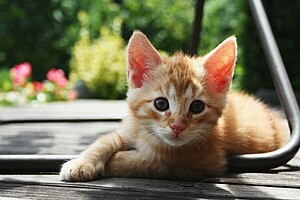

In [8]:
test_image

(1024, 1024)
(300, 200)


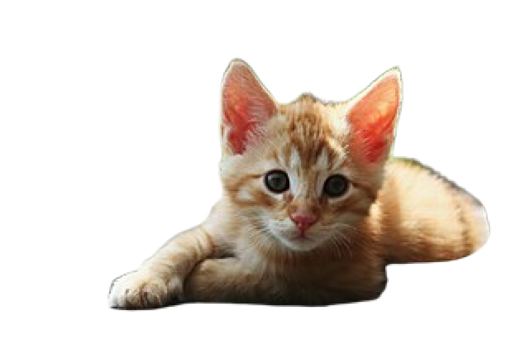

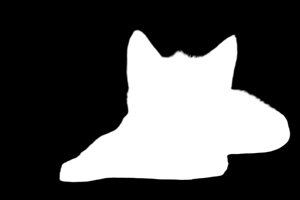

In [53]:
def extract_object(birefnet, image):
    image = image.copy()
    # Data settings
    image_size = (1024, 1024)
    image = pic2float(image)
    orgn_size = image.shape[:2]

    # image = pic2tensor(image).to('cuda')

    transform_image = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Resize(image_size),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    # image = image.copy()
    input_images = transform_image(image).to(torch.float16).unsqueeze(0).to("cuda")

    # Prediction
    with torch.no_grad():
        preds = birefnet(input_images)[-1].sigmoid().cpu()
    pred = preds[0].squeeze()
    pred_pil = transforms.ToPILImage()(pred)
    print(pred_pil.size)
    mask = pred_pil.resize(orgn_size[::-1])
    image = pic2pil(image)
    print(mask.size)
    # print(image.size)
    image.putalpha(mask)
    return image, mask, preds


image_alpha, mask, pred_pil = extract_object(birefnet, image=test_image)

# Visualization
plt.axis("off")
plt.imshow(image_alpha)
plt.show()

mask

In [45]:
pred_pil.squeeze().shape

torch.Size([1024, 1024])

In [ ]:
a = pic2float(test_image)
a = pic2float(a)
a

In [38]:
a = np.array(image_alpha)
a.shape

(200, 300, 4)

In [ ]:
MODEL_NAME = "ZhengPeng7/BiRefNet"
DTYPE = torch.float16


class BiRef_Predictor:
    def __init__(self, model=None, processor=None, device=None, model_name=MODEL_NAME, type=DTYPE):
        self.dtype = type

        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,  # включаем 4-битную квантизацию
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=False,
            bnb_4bit_quant_type="nf4",  # можно попробовать и другие варианты, например 'fp4'
        )

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = device

        if model is None:
            model = AutoModelForImageSegmentation.from_pretrained(
                model_name,
                trust_remote_code=True,
                torch_dtype=self.dtype,
                quantization_config=quant_config,
            )

        self.model = model.to(self.device)
        self.processor = processor

        self.proc_size = (1024, 1024)
        self.processor = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Resize(self.proc_size),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ]
        )

    def predict(self, image, sale_mask=False):
        image = pic2float(image)
        org_size = image.shape[:2]
        input = self.processor(image).to(self.dtype).unsqueeze(0).to("cuda")

        with torch.inference_mode():
            mask = self.model(input)[-1].sigmoid()

        if sale_mask:
            mask = transforms.Resize(org_size)(mask)

        return mask.squeeze().cpu().numpy()

In [4]:
pred = BiRef_Predictor()

N:\PROJECTS\python\STUDY\tg_pet_detector\tg_pet_detector_GUI\.venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
N:\PROJECTS\python\STUDY\tg_pet_detector\tg_pet_detector_GUI\.venv\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
`low_cpu_mem_usage` was None, now default to True since model is quantized.


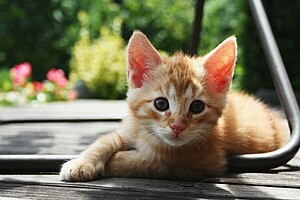

In [5]:
test_image

In [70]:
a = pred.predict(test_image)

In [72]:
a.shape

(1024, 1024)

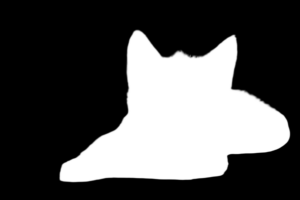

In [6]:
m = pred.predict(test_image, sale_mask=True)
a = pic2pil(m)
a

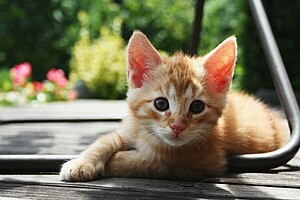

In [8]:
im = test_image
im

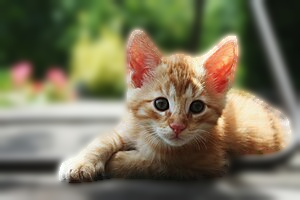

In [132]:
from matplotlib import pyplot as plt


def dec(im, mask, steps=5, blur=3):
    im = pic2float(im)
    mask = pic2float(mask)

    if len(mask.shape) == 2:
        mask = np.stack([mask, mask, mask], axis=-1)

    hm1 = (mask > 0.999).astype(np.float32)

    im_un = im

    for _ in range(steps):
        im_un = mask_blur(im_un, hm1, blur)
    # im = im_un*hm0 + im*(1-hm0)

    return im_un


def ummult(im, m):
    # im = pic2float(im)
    # m = pic2float(m)
    e = 0.00001
    return im / (m + e)


def mask_blur(im, m, b=3):
    # black = np.zeros_like(im)
    im_m = im * m
    im_m = cv2.GaussianBlur(im_m, (b, b), 0)
    im_b = cv2.GaussianBlur(im, (b, b), 0)
    mb = cv2.GaussianBlur(m, (b, b), 0)
    im_un = ummult(im_m, mb)
    hmb0 = mb > 0.001
    im_b = hmb0 * im_un + (1 - hmb0) * im_b

    im = im * m + (1 - m) * im_b

    return im


a = dec(im, m, steps=15, blur=5)


# sns.histplot(a.reshape(-1))

plt.show()
pic2pil(a)

In [ ]:
pic2pil(a)

In [134]:
import time

round(time.time(), 2)

1738095278.49

In [ ]:
# Imports
import torch
from PIL import Image

# from models.birefnet import BiRefNet


# Load Model
torch.set_float32_matmul_precision(["high", "highest"][0])
# model = BiRefNet.from_pretrained('zhengpeng7/birefnet')
model = AutoModelForImageSegmentation.from_pretrained("ZhengPeng7/BiRefNet", trust_remote_code=True)
model.to(device)
model.eval()
print("BiRefNet is ready to use.")

# Input Data
transform_image = transforms.Compose(
    [
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)
imagepath = "../image.jpg"


def pred_and_show(imagepath=imagepath, box=[-1, -1, -1, -1]):
    # box: left, top, right, bottom
    image = Image.open(imagepath)
    w, h = image.size[:2]
    for idx_coord_value, coord_value in enumerate(box):
        if coord_value == -1:
            box[idx_coord_value] = [0, 0, w, h][idx_coord_value]
    image_crop = image.crop(box)
    input_images = transform_image(image_crop).unsqueeze(0).to("cuda")

    # Prediction
    with torch.no_grad():
        preds = model(input_images)[-1].sigmoid().cpu()
    pred = preds[0].squeeze()

    canvas = torch.zeros_like(pred)
    box_to_canvas = [
        int(round(coord_value * (canvas.shape[-1] / w, canvas.shape[-2] / h)[idx_coord_value % 2]))
        for idx_coord_value, coord_value in enumerate(box)
    ]
    pred = torch.nn.functional.interpolate(
        pred.unsqueeze(0).unsqueeze(0),
        size=(box_to_canvas[3] - box_to_canvas[1], box_to_canvas[2] - box_to_canvas[0]),
        mode="bilinear",
        align_corners=True,
    ).squeeze()
    canvas[box_to_canvas[1] : box_to_canvas[3], box_to_canvas[0] : box_to_canvas[2]] = pred

    # Show Results
    pred_pil = transforms.ToPILImage()(canvas)
    # Scale proportionally with max length to 1024 for faster showing
    scale_ratio = 1024 / max(image.size)
    scaled_size = (int(image.size[0] * scale_ratio), int(image.size[1] * scale_ratio))
    image_masked = image.resize((1024, 1024))
    image_masked.putalpha(pred_pil)
    display(image_masked.resize(scaled_size))
    display(image.resize(scaled_size))
    display(pred_pil.resize(scaled_size))
    return pred_pil


pred_pil = pred_and_show(box=[666, 250, 1100, 777])

N:\PROJECTS\python\STUDY\tg_pet_detector\tg_pet_detector_GUI\.venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
N:\PROJECTS\python\STUDY\tg_pet_detector\tg_pet_detector_GUI\.venv\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
`low_cpu_mem_usage` was None, now default to True since model is quantized.


In [3]:
image_path = os.path.join(ROOT, "image.jpg")
image = Image.open(image_path)
image = pic2float(image)

In [4]:
image, mask = biref_process(image)
# mask = mask[:,:,None]
print(image.shape, mask.shape)

(200, 300, 3) (1024, 1024, 3)


In [ ]:
new_w, new_h = image.shape[:2]
cv2.resize(np.array(mask, dtype=np.float32), (new_w * 2, new_h // 2))

In [19]:
import numpy as np

params = {"rot": "45"}

params.get("text", 0)

0